In [1]:
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import sys

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')
sys.path.insert(0, '../../../../..')

# Decoding
import suffix_pred.evalaution.decode_test_set_suffixes
importlib.reload(suffix_pred.evalaution.decode_test_set_suffixes)
from suffix_pred.evalaution.decode_test_set_suffixes import TestSetSuffixDecoder, DecodingConfig

# Evaluation metrics
import suffix_pred.evalaution.evalaution_metrics
importlib.reload(suffix_pred.evalaution.evalaution_metrics)
from suffix_pred.evalaution.evalaution_metrics import evaluate_dls, dls_per_prefix_length, average_dls

# Model
import suffix_pred.models.T_GAN_LSTM
importlib.reload(suffix_pred.models.T_GAN_LSTM)
from suffix_pred.models.T_GAN_LSTM import TaymouriAdversarialLSTM

In [2]:
# Model
file_path_model = '../../../../../../models/Procurement/decision/Procurement_T_GAN_LSTM_v1_DA.pkl'
model = TaymouriAdversarialLSTM.load(file_path_model)

# Load the data
# Path to your pickle file (saved with torch.save)
file_path_test = '../../../../../../data/Procurement/tensor_data/normal/procurement_all_5_test.pkl'
# Load the dataset using torch.load
test_dataset = torch.load(file_path_test, weights_only=False)

/home/PSPLab/.local/share/virtualenvs/decision_aware_augmentation_for_PPM-0DzgvVpC/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [3]:
# Step 1: Decode suffixes (beam search)
config = DecodingConfig(concept_name="concept:name",
                        eos_value="EOS",
                        beam_width=3)

decoder = TestSetSuffixDecoder(model=model, dataset=test_dataset, config=config)

mode = "beam"
outputs = decoder.decode(mode=mode,
                         random_order=False,
                         cache_path='../../../../../../eval_results/Procurement/decision_train/procurement_t_gan_lstm_decision_train_outputs.pkl',
                         reuse_cache=False)

print(f"Decoded {len(outputs)} prefix rows in '{mode}' mode")

# Step 2: Evaluate DLS from decoded outputs
beam_df = evaluate_dls(outputs)
beam_per_prefix = dls_per_prefix_length(beam_df)
beam_avg = average_dls(beam_df)

print(f"Average DLS ({mode}) on full test set: {beam_avg:.4f}")

  0%|          | 0/2000 [00:00<?, ?it/s]

Decoded 23584 prefix rows in 'beam' mode


Average DLS (beam) on full test set: 0.7282


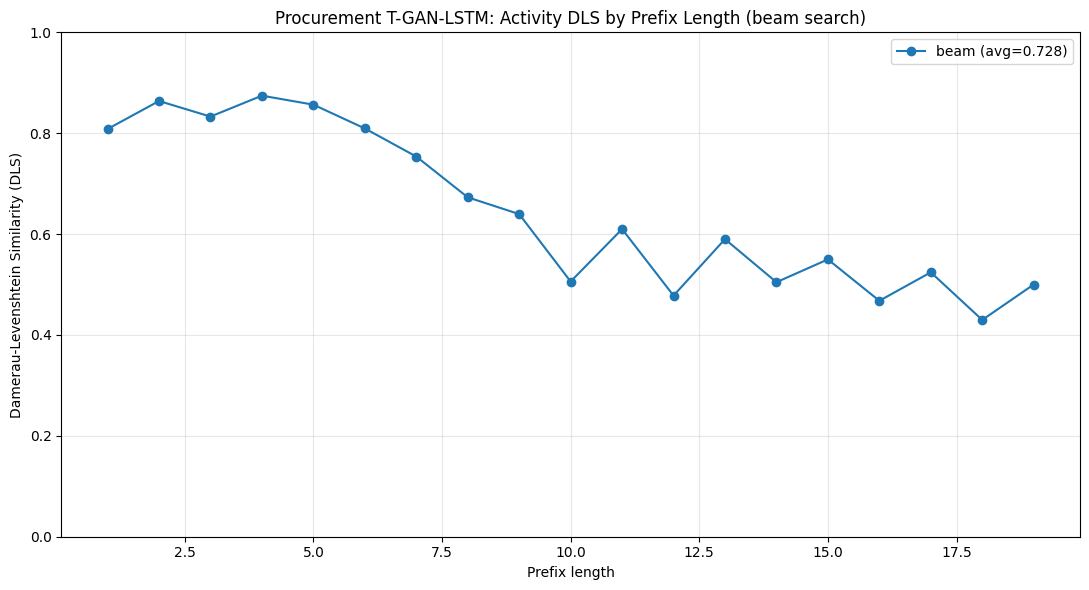

,mode,average_dls
0,beam,0.728182


In [4]:
# One combined plot (single method requested: beam search only)
plt.figure(figsize=(11, 6))

plt.plot(beam_per_prefix["prefix_len"],
         beam_per_prefix["dls"],
         marker="o",
         label=f"beam (avg={beam_avg:.3f})")

plt.title("Procurement T-GAN-LSTM: Activity DLS by Prefix Length (beam search)")
plt.xlabel("Prefix length")
plt.ylabel("Damerau-Levenshtein Similarity (DLS)")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional summary table
summary = pd.DataFrame({"mode": [mode], "average_dls": [beam_avg]}).sort_values("average_dls", ascending=False).reset_index(drop=True)
summary

In [5]:
# Load decoded outputs from pickle and inspect 5 example prefixes (full beam)
from suffix_pred.evalaution.evalaution_metrics import load_decoded_suffixes

cached_outputs = load_decoded_suffixes('../../../../../../eval_results/Procurement/decision_train/procurement_t_gan_lstm_decision_train_outputs.pkl')

for row in cached_outputs[:5]:
    print(f"Case: {row['case_id']}  |  Prefix len: {row['prefix_len']}")
    print(f"  Prefix:            {row['prefix']}")
    print(f"  Target suffix:     {row['target_suffix']}")
    decoded = row["decoded_suffixes"]
    for k, beam in enumerate(decoded):
        print(f"  Beam {k+1}:            {beam}")
    print()

Case: C00009  |  Prefix len: 1
  Prefix:            ['Create Purchase Requisition']
  Target suffix:     ['Approve Requisition', 'Collect Quotations', 'Evaluate Quotations', 'Select Supplier', 'Create Purchase Order', 'Send Purchase Order', 'Receive Goods', 'Approve Invoice', 'Pay Invoice', 'Close Case']
  Beam 1:            ['Reject Requisition', 'Revise Requisition', 'Approve Requisition', 'Collect Quotations', 'Evaluate Quotations', 'Select Supplier', 'Create Purchase Order', 'Send Purchase Order', 'Receive Goods', 'Approve Invoice', 'Pay Invoice', 'Close Case']
  Beam 2:            ['Approve Requisition', 'Revise Requisition', 'Approve Requisition', 'Collect Quotations', 'Evaluate Quotations', 'Select Supplier', 'Create Purchase Order', 'Send Purchase Order', 'Receive Goods', 'Approve Invoice', 'Pay Invoice', 'Close Case']
  Beam 3:            ['Reject Requisition', 'Revise Requisition', 'Reject Requisition', 'Revise Requisition', 'Approve Requisition', 'Collect Quotations', 'Evalu